Q1：Kafka 为什么要移除 Zookeeper？

答：
- 运维复杂（双系统）
- ZK 是瓶颈
- Kafka 自己已经有日志 & 复制能力
- 用 Raft 更自然

Q2：KRaft 里的 Controller 是什么？

答：
- Controller 是 Kafka 内部角色
- 使用 Raft 协议管理 metadata
- 多 controller 组成 quorum
- 保证一致性 & leader 选举


Q3：生产环境还用 Zookeeper 吗？

答（成熟版）：

“Older clusters may still use ZooKeeper, but all new Kafka deployments should use KRaft.”

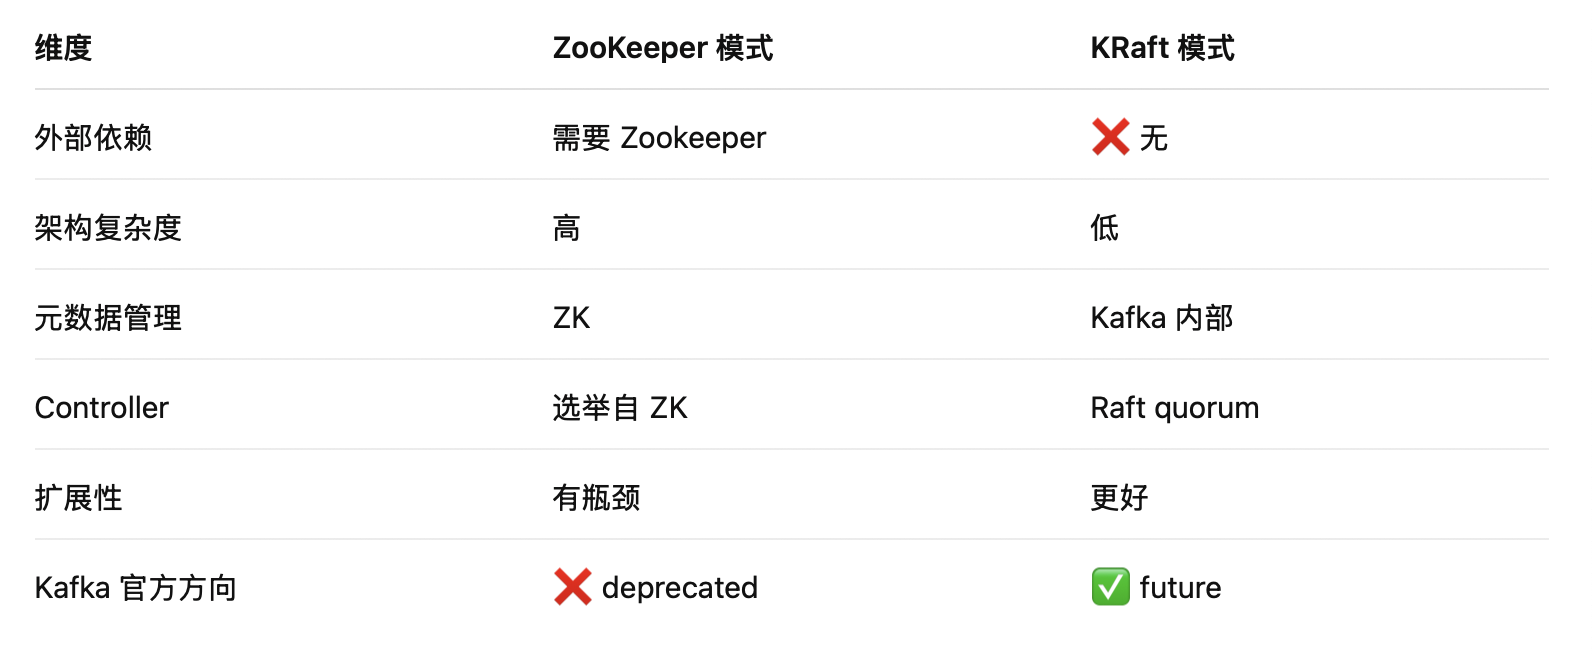

Q1：为什么扩容 partition 会影响 ordering？

答：
	•	partition 是并行单元
	•	每个 partition 独立维护 offset
	•	consumer 并发消费 → 无全局顺序

⸻

Q2：如何既保证顺序又提高吞吐？

答：
	•	按业务 key 分区（如 userId / orderId）
	•	顺序只要求 key 级别
	•	利用 partition 并行

⸻

Q3：能不能恢复 1 个 partition？

❌ 不能

Kafka 不支持减少 partition

⸻

📌 一句话总结（必背）

Ordering in Kafka is guaranteed per partition, not per topic.